In [1]:
import os
os.environ["HF_HOME"] = "/workspace/cache/huggingface"
os.environ["INSIGHTFACE_HOME"] = "/workspace/cache/insightface"
os.makedirs("/workspace/cache/huggingface", exist_ok=True)
os.makedirs("/workspace/cache/insightface", exist_ok=True)
print("Caches set up")

Caches set up


In [2]:
!pip install diffusers==0.30.3 transformers==4.44.2


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import os
os.chdir("/workspace/LoRA-scale-adaptive-feedback")
import sys
sys.path.insert(0, "src")

# Verify everything is in place
print("LoRAs:")
!ls -lh data/loras/
print("\nReference faces:")
!ls data/reference_faces/
print("\nPose images:")
!ls data/pose_images/
print("\nSource files:")
!ls src/*.py

LoRAs:
total 654M
-rw-rw-rw- 1 root root 436M Mar 29 18:46 daenerys.safetensors
-rw-rw-rw- 1 root root 218M Mar 29 18:44 hermonie.safetensors

Reference faces:
reference_daenerys.png	reference_hermione.png

Pose images:
two_person_pose.png

Source files:
src/adaptive_loop.py  src/extract_reference.py	src/pose_scorer.py
src/attention.py      src/generate_pose.py	src/scorer.py
src/evaluate.py       src/pipeline.py		src/sweep.py


In [4]:
# Check GPU
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

import psutil
ram = psutil.virtual_memory()
print(f"System RAM: {ram.total / 1024**3:.1f} GB")

GPU: NVIDIA GeForce RTX 3090
VRAM: 23.6 GB
System RAM: 1007.6 GB


In [5]:
from pipeline import load_identities, build_pipeline
from PIL import Image

identities = load_identities()
pipe = build_pipeline(identities)

pose_image = Image.open("data/pose_images/two_person_pose.png").convert("RGB")
print("Pipeline built!")

[pipeline] device=cuda  dtype=torch.float16
[pipeline] Loading ControlNet: thibaud/controlnet-openpose-sdxl-1.0


An error occurred while trying to fetch thibaud/controlnet-openpose-sdxl-1.0: thibaud/controlnet-openpose-sdxl-1.0 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


[pipeline] Loading VAE: madebyollin/sdxl-vae-fp16-fix
[pipeline] Loading base model: stabilityai/stable-diffusion-xl-base-1.0


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

[pipeline] Loading LoRA 'hermione' from data/loras/hermonie.safetensors
[pipeline] Loading LoRA 'daenerys' from data/loras/daenerys.safetensors


/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


[pipeline] Active adapters: ['hermione', 'daenerys']
Pipeline built!


In [6]:
from scorer import FaceScorer
from pose_scorer import PoseScorer

face_scorer = FaceScorer(reference_dir="data/reference_faces", device="cuda")
pose_scorer = PoseScorer()
target_keypoints = pose_scorer.extract_and_cache_target(pose_image)
print("Scorers ready!")

/usr/local/lib/python3.11/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

/usr/local/lib/python3.11/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[scorer] Loaded reference embedding for 'hermione' (from reference_hermione.png)
[scorer] Loaded reference embedding for 'daenerys' (from reference_daenerys.png)
[pose_scorer] Loading OpenPose detector...


/usr/local/lib/python3.11/dist-packages/controlnet_aux/open_pose/body.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = util.transfer(self.model, torch.load(

[pose_scorer] Ready.
[pose_scorer] Extracted 0 person(s) from target skeleton
Scorers ready!


In [7]:
from generate_pose import make_synthetic_two_person_pose

# These are the exact coordinates from generate_pose.py, normalized to [0,1]
person1 = [
    (0.30, 0.18, 1.0), (0.30, 0.25, 1.0), (0.24, 0.27, 1.0), (0.20, 0.37, 1.0),
    (0.18, 0.45, 1.0), (0.36, 0.27, 1.0), (0.40, 0.37, 1.0), (0.42, 0.45, 1.0),
    (0.26, 0.45, 1.0), (0.25, 0.60, 1.0), (0.25, 0.75, 1.0), (0.34, 0.45, 1.0),
    (0.35, 0.60, 1.0), (0.35, 0.75, 1.0), (0.28, 0.16, 1.0), (0.32, 0.16, 1.0),
    (0.25, 0.17, 1.0), (0.35, 0.17, 1.0),
]

person2 = [
    (0.70, 0.18, 1.0), (0.70, 0.25, 1.0), (0.64, 0.27, 1.0), (0.60, 0.37, 1.0),
    (0.58, 0.45, 1.0), (0.76, 0.27, 1.0), (0.80, 0.37, 1.0), (0.82, 0.45, 1.0),
    (0.66, 0.45, 1.0), (0.65, 0.60, 1.0), (0.65, 0.75, 1.0), (0.74, 0.45, 1.0),
    (0.75, 0.60, 1.0), (0.75, 0.75, 1.0), (0.68, 0.16, 1.0), (0.72, 0.16, 1.0),
    (0.65, 0.17, 1.0), (0.75, 0.17, 1.0),
]

target_keypoints = [person1, person2]
print(f"Target keypoints: {len(target_keypoints)} persons, 18 keypoints each")

Target keypoints: 2 persons, 18 keypoints each


Regional attention set: 140 layers masked
[pipeline] Regional attention enabled: {'hermione': (0, 0, 512, 1024), 'daenerys': (512, 0, 1024, 1024)}
[pipeline] Prompt: portrait photo of Hermione_Granger on the left and dae woman on the right, two people, soft natural lighting, high quality


  0%|          | 0/30 [00:00<?, ?it/s]

Regional attention removed, default processors restored
Generated in 31.5s
hermione: arcface=0.272
daenerys: arcface=0.252
hermione: pose=0.968
daenerys: pose=0.156


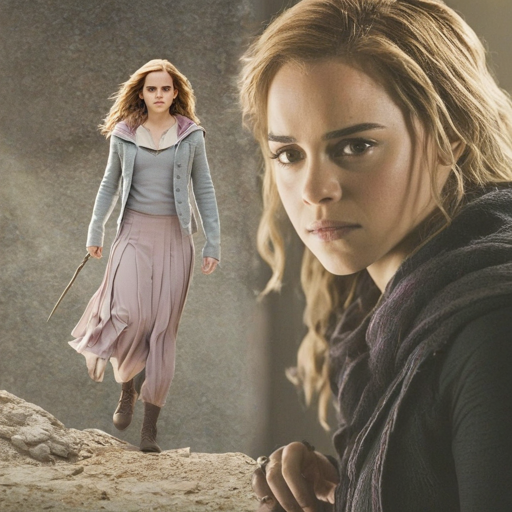

In [8]:
from pipeline import generate
import time

names = list(identities.keys())
identity_regions = {
    names[0]: (0, 0, 512, 1024),
    names[1]: (512, 0, 1024, 1024),
}

t0 = time.time()
test_img = generate(pipe, identities, pose_image, seed=42,
                    use_regional_attention=True, identity_regions=identity_regions)
print(f"Generated in {time.time()-t0:.1f}s")

face_scores = face_scorer.score_image(test_img, identity_regions)
pose_scores = pose_scorer.score_image(test_img, target_keypoints, identity_regions)

for k, v in face_scores.items():
    print(f"{k}: arcface={v['arcface']:.3f}")
for k, v in pose_scores.items():
    print(f"{k}: pose={v['pose']:.3f}")

display(test_img.resize((512, 512)))
del test_img; torch.cuda.empty_cache()

  0%|          | 0/30 [00:00<?, ?it/s]

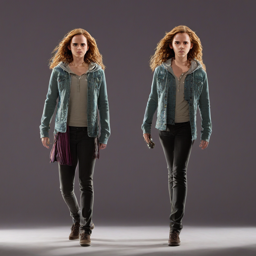

  0%|          | 0/30 [00:00<?, ?it/s]

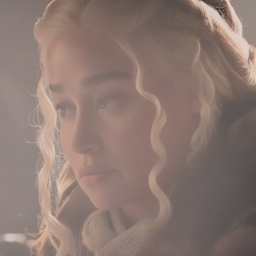

In [11]:
# Test Hermione LoRA alone
pipe.set_adapters(["hermione"], adapter_weights=[1.0])
img_h = pipe(
    prompt="portrait photo of Hermione_Granger, one person, soft lighting, high quality",
    negative_prompt="blurry, low quality, deformed",
    image=pose_image.resize((1024, 1024)),
    controlnet_conditioning_scale=0.7,
    generator=torch.Generator(device="cpu").manual_seed(42),
    num_inference_steps=30, width=1024, height=1024,
).images[0]
display(img_h.resize((256, 256)))

# Test Daenerys LoRA alone
pipe.set_adapters(["daenerys"], adapter_weights=[1.0])
img_d = pipe(
    prompt="portrait photo of dae woman, one person, soft lighting, high quality",
    negative_prompt="blurry, low quality, deformed",
    image=pose_image.resize((1024, 1024)),
    controlnet_conditioning_scale=0.7,
    generator=torch.Generator(device="cpu").manual_seed(42),
    num_inference_steps=30, width=1024, height=1024,
).images[0]
display(img_d.resize((256, 256)))

# Reset both adapters
pipe.set_adapters(list(identities.keys()), adapter_weights=[1.0, 1.0])

In [12]:
from sweep import run_default_baseline, run_static_sweep, SEEDS, LORA_SCALES, CTRL_SCALES

os.makedirs("data/results/sweep", exist_ok=True)

df_default = run_default_baseline(
    pipe, identities, pose_image,
    face_scorer, pose_scorer, target_keypoints, identity_regions,
    output_dir="data/results/sweep", seeds=SEEDS,
    save_images=True, use_regional_attention=True,
)

df_sweep = run_static_sweep(
    pipe, identities, pose_image,
    face_scorer, pose_scorer, target_keypoints, identity_regions,
    output_dir="data/results/sweep",
    lora_scales=LORA_SCALES, ctrl_scales=CTRL_SCALES, seeds=SEEDS,
    save_images=True, use_regional_attention=True,
)


BASELINE 1: Default Weights
  LoRA scale = 1.0, ControlNet scale = 0.7

[default] (1/3)  seed=42
Regional attention set: 140 layers masked
[pipeline] Regional attention enabled: {'hermione': (0, 0, 512, 1024), 'daenerys': (512, 0, 1024, 1024)}
[pipeline] Prompt: portrait photo of Hermione_Granger on the left and dae woman on the right, two people, soft natural lighting, high quality


  0%|          | 0/30 [00:00<?, ?it/s]

Regional attention removed, default processors restored


/usr/local/lib/python3.11/dist-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  avg_arcface=0.2093  avg_pose=0.6463  gen_time=24.99s  peak_mem=9443.7MB

[default] (2/3)  seed=123
Regional attention set: 140 layers masked
[pipeline] Regional attention enabled: {'hermione': (0, 0, 512, 1024), 'daenerys': (512, 0, 1024, 1024)}
[pipeline] Prompt: portrait photo of Hermione_Granger on the left and dae woman on the right, two people, soft natural lighting, high quality


...

Regional attention removed, default processors restored
  avg_arcface=0.2139  avg_pose=0.6447  gen_time=24.82s  peak_mem=9443.7MB

[sweep] (47/48)  lora=1.0  ctrl=0.9  seed=123
Regional attention set: 140 layers masked
[pipeline] Regional attention enabled: {'hermione': (0, 0, 512, 1024), 'daenerys': (512, 0, 1024, 1024)}
[pipeline] Prompt: portrait photo of Hermione_Granger on the left and dae woman on the right, two people, soft natural lighting, high quality


  0%|          | 0/30 [00:00<?, ?it/s]

Regional attention removed, default processors restored
  avg_arcface=0.2333  avg_pose=0.8566  gen_time=24.14s  peak_mem=9443.7MB

[sweep] (48/48)  lora=1.0  ctrl=0.9  seed=777
Regional attention set: 140 layers masked
[pipeline] Regional attention enabled: {'hermione': (0, 0, 512, 1024), 'daenerys': (512, 0, 1024, 1024)}
[pipeline] Prompt: portrait photo of Hermione_Granger on the left and dae woman on the right, two people, soft natural lighting, high quality


  0%|          | 0/30 [00:00<?, ?it/s]

Regional attention removed, default processors restored
  avg_arcface=0.1833  avg_pose=0.9873  gen_time=24.66s  peak_mem=9443.7MB

SWEEP COMPLETE
  Total time: 1640.4s (27.3 min)
  Images generated: 48
  Results: data/results/sweep/sweep_results.csv

  Best by ArcFace:
    lora=0.4  ctrl=0.3  seed=42
    avg_arcface=0.4741  avg_pose=0.0983

  Best by Pose:
    lora=0.8  ctrl=0.9  seed=777
    avg_arcface=0.1305  avg_pose=0.9891

  Best Combined (arcface + pose / 2):
    lora=1.0  ctrl=0.9  seed=777
    avg_arcface=0.1833  avg_pose=0.9873
